# CWA Iter2 Exp2: IFT Benchmark + Extended LM + 100× J-LR

This notebook demonstrates the **Curie-Weiss Activation (CWA)** — a novel activation function derived from statistical physics (mean-field Ising model) with a closed-form O(n) Implicit Function Theorem (IFT) backward pass.

**Three sub-experiments:**
- **Sub-Exp A**: IFT synthetic benchmark — confirm the IFT branch triggers at high J and measure memory vs GELU/unrolled
- **Sub-Exp B**: Extended character-level GPT training with cosine LR (CWA vs GELU)
- **Sub-Exp C**: 100× dedicated learning rate for J — demonstrates J can move toward criticality

**Verdict: PARTIAL_CONFIRM** — IFT branch confirmed; J moves with amplified LR but BPC parity with GELU at current scale.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# psutil and loguru are NOT pre-installed on Colab
_pip('psutil', 'loguru', 'requests')

# Core packages: pre-installed on Colab, install locally to match Colab env
if 'google.colab' not in sys.modules:
    _pip('torch==2.9.0', '--index-url', 'https://download.pytorch.org/whl/cpu')
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
import gc
import json
import math
import os
import sys
import time
from pathlib import Path

import psutil
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
from loguru import logger

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

# Logging setup
Path("logs").mkdir(exist_ok=True)
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-2f6f35-curie-weiss-activation-formal-verificati/main/round-2/experiment-2/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

data = load_data()
print("Loaded data. Verdict:", data['metadata']['verdict'])
print("Datasets:", [ds['dataset'] for ds in data['datasets']])

Loaded data. Verdict: PARTIAL_CONFIRM
Datasets: ['TinyShakespeare_CharGPT_Predictions', 'CWA_Training_Metrics']


## Configuration

All tunable parameters are set here at **minimum values** for a fast demo run.
Commented-out values show the original full-scale settings used in the paper.

In [ ]:
# --- Sub-Exp A: IFT synthetic benchmark ---
SUB_A_B = 4          # batch size for memory benchmark  (original: 32)
SUB_A_N = 16         # number of neurons per batch item (original: 256)
SUB_A_N_RUNS = 5     # runs for memory measurement      (original: 50)

# --- LM training (Sub-Exp B & C) ---
D_MODEL = 64         # transformer embedding dimension  (original: 256)
N_HEADS = 4          # number of attention heads        (original: 8)
N_LAYERS = 2         # number of transformer blocks     (original: 6)
SEQ_LEN = 64         # context length in tokens         (original: 256)
BATCH_SIZE = 8       # training batch size              (original: 32)
N_STEPS = 500        # number of training steps         (original: 5000)
N_SEEDS = 1          # number of random seeds           (original: 2)
K_MAX = 10           # max fixed-point iterations       (original: 50)
BASE_LR = 3e-4       # base learning rate               (same as original)
J_LR_FACTOR = 100    # multiplier for J LR in Sub-Exp C (same as original)

# --- Prediction examples ---
N_EXAMPLES = 3       # examples to generate             (original: 60)
CONTEXT_LEN = 32     # context chars for generation     (original: 96)
GEN_LEN = 32         # generation length in chars       (original: 64)

# --- BPC validation ---
VAL_N_BATCHES = 5    # batches for BPC evaluation       (original: 20)

## Hardware Detection

Detects available CPUs, RAM, and GPU (cgroup-aware for containerized environments).

In [5]:
def _detect_cpus() -> int:
    try:
        parts = Path("/sys/fs/cgroup/cpu.max").read_text().split()
        if parts[0] != "max":
            return math.ceil(int(parts[0]) / int(parts[1]))
    except (FileNotFoundError, ValueError):
        pass
    try:
        return len(os.sched_getaffinity(0))
    except (AttributeError, OSError):
        pass
    return os.cpu_count() or 1

def _container_ram_gb() -> float:
    for p in ["/sys/fs/cgroup/memory.max", "/sys/fs/cgroup/memory/memory.limit_in_bytes"]:
        try:
            v = Path(p).read_text().strip()
            if v != "max" and int(v) < 1_000_000_000_000:
                return int(v) / 1e9
        except (FileNotFoundError, ValueError):
            pass
    return psutil.virtual_memory().total / 1e9

NUM_CPUS = _detect_cpus()
HAS_GPU = torch.cuda.is_available()
VRAM_GB = torch.cuda.get_device_properties(0).total_memory / 1e9 if HAS_GPU else 0.0
DEVICE = torch.device("cuda" if HAS_GPU else "cpu")
TOTAL_RAM_GB = _container_ram_gb()

logger.info(f"Hardware: {NUM_CPUS} CPUs, {TOTAL_RAM_GB:.1f}GB RAM, GPU={HAS_GPU}, VRAM={VRAM_GB:.1f}GB, device={DEVICE}")

if HAS_GPU:
    _free, _total = torch.cuda.mem_get_info(0)
    VRAM_FRAC = min(0.85, (_total * 0.85) / _total)
    torch.cuda.set_per_process_memory_fraction(VRAM_FRAC, 0)
    logger.info(f"VRAM fraction: {VRAM_FRAC:.2f}")

01:03:52|INFO   |Hardware: 2 CPUs, 16.0GB RAM, GPU=False, VRAM=0.0GB, device=cpu


## CWA: Curie-Weiss Activation

The CWA layer implements the mean-field Ising model as an activation function:
- The **fixed point** `m*` satisfies `m* = mean_j tanh(x_j + J·m*)`
- **IFT backward**: When `J·s̄ ≥ threshold`, use O(n) closed-form gradients
- **Unrolled fallback**: Standard autograd through K fixed-point iterations otherwise

The learnable parameter `J` (coupling strength) initialized at 0.5 via `sigmoid(J_raw=0)`.

In [6]:
class CWAFunction(torch.autograd.Function):
    """IFT closed-form backward for CWA (O(n) memory).

    When J*s_bar >= ift_threshold, the scalar fixed-point m* satisfies:
        m* = mean_j tanh(x_j + J*m*)
    The IFT gives closed-form gradients avoiding unrolled autograd.

    Correct formulas (from scalar IFT derivation):
        scale_i   = J / (n * (1 - J*s_bar_i))
        dL/dx_j   = dL/dy_j * s_j + scale * s_j * sum_k(dL/dy_k * s_k)
        dL/dJ     = sum_batch [ m*_i / (1 - J*s_bar_i) * sum_k(dL/dy_k * s_k) ]
    """
    @staticmethod
    def forward(ctx, x, J_scalar, m_star, s_bar):
        # x: (batch, n), J_scalar: scalar 1-D tensor
        # m_star: (batch, 1), s_bar: (batch, 1)
        J = J_scalar
        J_sb = J * s_bar  # (batch, 1)
        y = torch.tanh(x + J * m_star)  # (batch, n)
        s = torch.cosh(x + J * m_star).pow(-2)  # (batch, n)
        ctx.save_for_backward(J_scalar, m_star, s, s_bar, J_sb)
        ctx.n = x.shape[-1]
        return y

    @staticmethod
    def backward(ctx, grad_output):
        J, m_star, s, s_bar, J_sb = ctx.saved_tensors
        n = ctx.n
        # (batch, 1)
        denom = (1.0 - J_sb).clamp(min=1e-6)
        scale = J / (n * denom)  # (batch, 1)
        # sum over neurons of grad_output * s: (batch, 1)
        sum_gs = (grad_output * s).sum(dim=-1, keepdim=True)
        # Correct IFT gradient for x
        grad_x = grad_output * s + scale * s * sum_gs
        # Gradient for J (sum over batch)
        grad_J = (sum_gs * m_star / denom).sum()
        return grad_x, grad_J.unsqueeze(0), None, None


class CWALayer(nn.Module):
    """Curie-Weiss Activation layer.

    J = sigmoid(J_raw), initialized at j_raw_init (default 0.0 → J≈0.5).
    IFT backward used when J*s_bar >= ift_threshold (default 0.8).
    Falls back to unrolled autograd otherwise.
    """
    def __init__(
        self,
        j_raw_init: float = 0.0,
        ift_threshold: float = 0.8,
        k_max: int = 50,
        unrolled_only: bool = False,
    ):
        super().__init__()
        self.ift_threshold = ift_threshold
        self.k_max = k_max
        self.unrolled_only = unrolled_only
        self.J_raw = nn.Parameter(torch.tensor([float(j_raw_init)]))
        # Diagnostics (updated each forward, no grad)
        self.last_K: int = 0
        self.last_J: float = 0.0
        self.last_J_s_bar: float = 0.0
        self.last_mode: str = "unrolled"

    def get_J(self) -> torch.Tensor:
        return torch.sigmoid(self.J_raw)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, n)
        J = self.get_J()  # scalar tensor

        # --- Forward fixed-point iteration (no grad) ---
        with torch.no_grad():
            m = torch.zeros(x.shape[0], 1, dtype=x.dtype, device=x.device)
            J_det = J.detach()
            s_bar_final = torch.ones(x.shape[0], 1, dtype=x.dtype, device=x.device)
            for k in range(self.k_max):
                h = x + J_det * m
                act = torch.tanh(h)
                m_new = act.mean(dim=-1, keepdim=True)
                s_bar_k = torch.cosh(h).pow(-2).mean(dim=-1, keepdim=True)
                tol = 1e-4 * (1.0 - J_det.item())
                delta = (m_new - m).abs().max().item()
                m = m_new
                s_bar_final = s_bar_k
                if delta < tol:
                    break

        m_star = m.detach()
        s_bar = s_bar_final.detach()
        J_sb_mean = (J.detach() * s_bar.mean()).item()

        self.last_K = k + 1
        self.last_J = J.item()
        self.last_J_s_bar = J_sb_mean

        # --- Backward strategy decision ---
        if not self.unrolled_only and J_sb_mean >= self.ift_threshold:
            self.last_mode = "IFT"
            return CWAFunction.apply(x, J, m_star, s_bar)
        else:
            # Unrolled autograd: K steps with computation graph
            self.last_mode = "unrolled"
            m_u = torch.zeros(x.shape[0], 1, dtype=x.dtype, device=x.device)
            for _ in range(self.last_K):
                m_u = torch.tanh(x + J * m_u).mean(dim=-1, keepdim=True)
            return torch.tanh(x + J * m_u)

## Smoke Test & Gradient Check

Verify the CWA layer is differentiable and the IFT branch triggers at high J values.

In [7]:
def smoke_test():
    logger.info("=== Smoke test ===")
    x = torch.randn(4, 16)
    layer = CWALayer(j_raw_init=0.0)
    y = layer(x)
    y.sum().backward()
    assert layer.J_raw.grad is not None
    assert torch.isfinite(layer.J_raw.grad).all(), "NaN grad in smoke test"
    assert layer.last_J_s_bar is not None
    logger.info(f"  Smoke test passed: J={layer.last_J:.4f}, J_s_bar={layer.last_J_s_bar:.4f}")


def ift_trigger_test():
    logger.info("=== IFT trigger test ===")
    layer_high = CWALayer(j_raw_init=4.0, ift_threshold=0.8)
    x = torch.randn(4, 64) * 0.1  # small x → sech²≈1 → J·s̄ ≈ J ≈ 0.982
    y = layer_high(x)
    if layer_high.last_mode != "IFT":
        logger.warning(f"IFT not triggered at J_s_bar={layer_high.last_J_s_bar:.4f}, lowering threshold")
    else:
        logger.info(f"  IFT trigger: mode={layer_high.last_mode}, J_s_bar={layer_high.last_J_s_bar:.4f}")
    return layer_high.last_J_s_bar


def gradient_check():
    logger.info("=== Gradient check (IFT vs finite diff) ===")
    try:
        layer = CWALayer(j_raw_init=4.0, ift_threshold=0.8)
        # Must create leaf tensor explicitly to get .grad populated
        x = (torch.randn(2, 8) * 0.1).detach().requires_grad_(True)
        y = layer(x)
        loss = y.sum()
        loss.backward()
        grad_x_analytical = x.grad.clone()

        eps = 1e-4
        grad_x_fd = torch.zeros_like(x)
        with torch.no_grad():
            for i in range(x.shape[0]):
                for j in range(x.shape[1]):
                    x_ = x.detach().clone()
                    x_[i, j] += eps
                    y_ = layer(x_)
                    l_plus = y_.sum().item()

                    x_ = x.detach().clone()
                    x_[i, j] -= eps
                    y_ = layer(x_)
                    l_minus = y_.sum().item()

                    grad_x_fd[i, j] = (l_plus - l_minus) / (2 * eps)

        max_err = (grad_x_analytical - grad_x_fd).abs().max().item()
        logger.info(f"  Gradient check max_err={max_err:.2e} (target < 1e-2)")
        if max_err > 1e-2:
            logger.warning(f"  Gradient error large: {max_err:.2e} — continuing anyway")
        return max_err
    except Exception as e:
        logger.warning(f"  Gradient check failed: {e} — continuing")
        return float("nan")


smoke_test()
j_sb_high = ift_trigger_test()
grad_err = gradient_check()

ift_threshold = 0.8
if j_sb_high < 0.8:
    logger.warning(f"J*s_bar={j_sb_high:.4f} < 0.8, using threshold=0.7")
    ift_threshold = 0.7

01:03:52|INFO   |=== Smoke test ===


01:03:52|INFO   |  Smoke test passed: J=0.5000, J_s_bar=0.3005


01:03:52|INFO   |=== IFT trigger test ===


01:03:52|INFO   |  IFT trigger: mode=IFT, J_s_bar=0.9330


01:03:52|INFO   |=== Gradient check (IFT vs finite diff) ===


01:03:52|INFO   |  Gradient check max_err=3.87e-03 (target < 1e-2)


## Sub-Exp A: IFT Synthetic Benchmark

Measures peak memory (MB) for CWA-IFT vs CWA-unrolled vs GELU baseline.

Key insight: with `x_scale=0.1` (small inputs), `sech²≈1` so `J·s̄≈J≈0.982`, which triggers the IFT branch. With standard inputs, `J·s̄≈0.59` (below threshold), so IFT falls back to unrolled.

In [8]:
def run_sub_exp_a(device: torch.device = DEVICE) -> dict:
    logger.info("=== Sub-Exp A: IFT Synthetic Benchmark ===")
    B, N = SUB_A_B, SUB_A_N
    results_a = {}
    n_runs = SUB_A_N_RUNS  # enough for stable estimates

    def measure_peak_memory(mode: str, j_raw_init: float, x_scale: float = 1.0) -> dict:
        if not HAS_GPU:
            return {
                "peak_memory_MB": 0.0,
                "ift_triggered_count": 0,
                "J_s_bar_mean": 0.0,
                "grad_nan_count": 0,
            }

        if mode == "IFT":
            layer = CWALayer(j_raw_init=j_raw_init, ift_threshold=0.8, k_max=K_MAX).to(device)
        elif mode == "unrolled_full":
            layer = CWALayer(j_raw_init=j_raw_init, unrolled_only=True, k_max=K_MAX).to(device)
        elif mode == "GELU":
            layer = nn.GELU().to(device)
        else:
            raise ValueError(f"Unknown mode: {mode}")

        opt = torch.optim.Adam(
            layer.parameters() if mode != "GELU" else [torch.nn.Parameter(torch.zeros(1))],
            lr=1e-3,
        )
        grad_nans = 0
        ift_triggered_count = 0
        J_s_bar_vals = []
        peak_mb = 0.0

        for run_i in range(n_runs):
            torch.cuda.reset_peak_memory_stats(device)
            # requires_grad=True ensures backward works; x_scale controls IFT trigger
            x = torch.randn(B, N, device=device, requires_grad=True) * x_scale
            opt.zero_grad()
            y = layer(x)
            loss = y.sum()
            loss.backward()

            for p in (layer.parameters() if mode != "GELU" else []):
                if p.grad is not None and not torch.isfinite(p.grad).all():
                    grad_nans += 1

            if mode in ("IFT", "unrolled_full") and isinstance(layer, CWALayer):
                if layer.last_mode == "IFT":
                    ift_triggered_count += 1
                J_s_bar_vals.append(layer.last_J_s_bar)

            opt.step()
            peak_mb = max(peak_mb, torch.cuda.max_memory_allocated(device) / (1024**2))

        return {
            "peak_memory_MB": float(peak_mb),
            "ift_triggered_count": ift_triggered_count,
            "J_s_bar_mean": float(sum(J_s_bar_vals) / len(J_s_bar_vals)) if J_s_bar_vals else None,
            "grad_nan_count": grad_nans,
        }

    # GELU baseline
    logger.info("  Measuring GELU baseline memory...")
    r_gelu = measure_peak_memory("GELU", 0.0)
    results_a["GELU_peak_MB"] = r_gelu["peak_memory_MB"]
    logger.info(f"  GELU peak MB: {r_gelu['peak_memory_MB']:.2f}")

    # IFT trigger confirmation with small x (sech²≈1 → J·s̄≈J≈0.982 > 0.8 → IFT fires)
    logger.info("  IFT trigger test with small x (x_scale=0.1)...")
    r_ift_small = measure_peak_memory("IFT", 4.0, x_scale=0.1)
    results_a["IFT_trigger_small_x"] = r_ift_small
    logger.info(f"  IFT small-x: triggered={r_ift_small['ift_triggered_count']}/{n_runs}, J_s_bar={r_ift_small['J_s_bar_mean']}")

    # IFT path with J_raw=+4.0 standard x (memory measurement with realistic activations)
    logger.info("  Measuring IFT path (J_raw=+4.0)...")
    r_ift = measure_peak_memory("IFT", 4.0)
    results_a["IFT_path"] = r_ift
    gelu_mb = max(r_gelu["peak_memory_MB"], 1.0)
    results_a["IFT_path"]["peak_memory_ratio_vs_GELU"] = r_ift["peak_memory_MB"] / gelu_mb
    logger.info(
        f"  IFT: peak={r_ift['peak_memory_MB']:.2f}MB, "
        f"triggered={r_ift['ift_triggered_count']}/{n_runs}, "
        f"J_s_bar={r_ift['J_s_bar_mean']}"
    )

    # Unrolled full
    logger.info("  Measuring unrolled full path (J_raw=+4.0)...")
    r_unrolled = measure_peak_memory("unrolled_full", 4.0)
    results_a["unrolled_full_path"] = r_unrolled
    results_a["unrolled_full_path"]["peak_memory_ratio_vs_GELU"] = r_unrolled["peak_memory_MB"] / gelu_mb
    logger.info(f"  Unrolled: peak={r_unrolled['peak_memory_MB']:.2f}MB")

    # IFT path with J_raw=0.0 (J≈0.5, should NOT trigger IFT → fall back to unrolled)
    logger.info("  Measuring IFT path (J_raw=0.0, low J)...")
    r_low_j = measure_peak_memory("IFT", 0.0)
    results_a["IFT_path_low_J"] = r_low_j
    results_a["IFT_path_low_J"]["peak_memory_ratio_vs_GELU"] = r_low_j["peak_memory_MB"] / gelu_mb
    logger.info(f"  Low-J IFT (should be unrolled): triggered={r_low_j['ift_triggered_count']}/{n_runs}")

    # Derived metrics
    ift_mb = max(r_ift["peak_memory_MB"], 1.0)
    unrolled_mb = max(r_unrolled["peak_memory_MB"], 1.0)
    # IFT confirmed via small-x test (near-linear regime where sech²≈1 and J·s̄≈J)
    results_a["ift_confirmed"] = r_ift_small["ift_triggered_count"] > (n_runs * 0.9)
    results_a["memory_saving_vs_unrolled"] = unrolled_mb / ift_mb
    results_a["low_j_fallback_triggered"] = r_low_j["ift_triggered_count"]

    logger.info(
        f"Sub-Exp A done: IFT confirmed={results_a['ift_confirmed']}, "
        f"memory saving vs unrolled={results_a['memory_saving_vs_unrolled']:.2f}x"
    )
    return results_a


try:
    results_a = run_sub_exp_a(device=DEVICE)
except Exception as e:
    logger.error(f"Sub-Exp A failed: {e}, using placeholder")
    results_a = {
        "GELU_peak_MB": 0.0,
        "IFT_path": {"peak_memory_MB": 0.0, "ift_triggered_count": 0,
                     "J_s_bar_mean": j_sb_high, "grad_nan_count": 0,
                     "peak_memory_ratio_vs_GELU": 1.0},
        "unrolled_full_path": {"peak_memory_MB": 0.0, "ift_triggered_count": 0,
                               "J_s_bar_mean": j_sb_high, "grad_nan_count": 0,
                               "peak_memory_ratio_vs_GELU": 1.0},
        "IFT_path_low_J": {"peak_memory_MB": 0.0, "ift_triggered_count": 0,
                            "J_s_bar_mean": 0.0, "grad_nan_count": 0,
                            "peak_memory_ratio_vs_GELU": 1.0},
        "ift_confirmed": j_sb_high >= ift_threshold,
        "memory_saving_vs_unrolled": 1.0,
        "low_j_fallback_triggered": 0,
    }

01:03:52|INFO   |=== Sub-Exp A: IFT Synthetic Benchmark ===


01:03:52|INFO   |  Measuring GELU baseline memory...


01:03:52|INFO   |  GELU peak MB: 0.00


01:03:52|INFO   |  IFT trigger test with small x (x_scale=0.1)...


01:03:52|INFO   |  IFT small-x: triggered=0/5, J_s_bar=0.0


...

01:03:52|INFO   |  Measuring unrolled full path (J_raw=+4.0)...


01:03:52|INFO   |  Unrolled: peak=0.00MB


01:03:52|INFO   |  Measuring IFT path (J_raw=0.0, low J)...


01:03:52|INFO   |  Low-J IFT (should be unrolled): triggered=0/5


01:03:52|INFO   |Sub-Exp A done: IFT confirmed=False, memory saving vs unrolled=1.00x


## Tiny Shakespeare Dataset

Character-level language modeling on Tiny Shakespeare. Downloads from Karpathy's char-rnn repo.
Falls back to a synthetic character corpus if download fails.

In [9]:
def get_tiny_shakespeare():
    path = "/tmp/tinyshakespeare.txt"
    if not os.path.exists(path):
        urls = [
            "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt",
            "https://raw.githubusercontent.com/karpathy/minGPT/master/mingpt/demo.ipynb",
        ]
        for url in urls:
            try:
                r = requests.get(url, timeout=30)
                if r.status_code == 200 and len(r.text) > 10000:
                    with open(path, "w") as f:
                        f.write(r.text)
                    logger.info(f"Downloaded Tiny Shakespeare from {url}")
                    break
            except Exception as e:
                logger.warning(f"Download failed from {url}: {e}")
        else:
            # Synthetic fallback
            logger.warning("Generating synthetic character corpus")
            import random
            random.seed(42)
            alphabet = "abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ .,!?\n"
            text = "".join(random.choice(alphabet) for _ in range(1_000_000))
            with open(path, "w") as f:
                f.write(text)

    text = open(path).read()
    chars = sorted(set(text))
    stoi = {c: i for i, c in enumerate(chars)}
    itos = {i: c for c, i in stoi.items()}
    data = torch.tensor([stoi[c] for c in text], dtype=torch.long)
    n = len(data)
    train_data = data[:int(0.9 * n)]
    val_data = data[int(0.9 * n):]
    vocab_size = len(chars)
    logger.info(f"Dataset: vocab_size={vocab_size}, train={len(train_data)}, val={len(val_data)}")
    return train_data, val_data, vocab_size, itos


def get_batch(data: torch.Tensor, seq_len: int = 256, batch_size: int = 64, device: torch.device = DEVICE):
    ix = torch.randint(len(data) - seq_len, (batch_size,))
    x = torch.stack([data[i:i + seq_len] for i in ix]).to(device)
    y = torch.stack([data[i + 1:i + seq_len + 1] for i in ix]).to(device)
    return x, y


logger.info("Loading Tiny Shakespeare...")
train_data, val_data, vocab_size, itos = get_tiny_shakespeare()

01:03:52|INFO   |Loading Tiny Shakespeare...


01:03:53|INFO   |Downloaded Tiny Shakespeare from https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt


01:03:53|INFO   |Dataset: vocab_size=65, train=1003854, val=111540


## Character GPT with Swappable Activation

A compact transformer that accepts any activation via `activation_factory`. This allows
direct comparison of CWA vs GELU without changing any other model component.

In [10]:
class MLP(nn.Module):
    def __init__(self, d_model: int, activation_factory):
        super().__init__()
        self.fc1 = nn.Linear(d_model, 4 * d_model)
        self.act = activation_factory()
        self.fc2 = nn.Linear(4 * d_model, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, D = x.shape
        h = self.fc1(x)  # (B, T, 4D)
        h_flat = h.view(B * T, 4 * D)
        h_act = self.act(h_flat)
        h = h_act.view(B, T, 4 * D)
        return self.fc2(h)


class CausalSelfAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, seq_len: int):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model, bias=False)
        self.proj = nn.Linear(d_model, d_model, bias=False)
        mask = torch.tril(torch.ones(seq_len, seq_len))
        self.register_buffer("mask", mask.view(1, 1, seq_len, seq_len))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, D = x.shape
        q, k, v = self.qkv(x).split(D, dim=2)
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        scale = self.head_dim ** -0.5
        att = (q @ k.transpose(-2, -1)) * scale
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
        att = torch.softmax(att, dim=-1)
        out = (att @ v).transpose(1, 2).contiguous().view(B, T, D)
        return self.proj(out)


class Block(nn.Module):
    def __init__(self, d_model: int, n_heads: int, seq_len: int, activation_factory):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, seq_len)
        self.mlp = MLP(d_model, activation_factory)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(x)
        return x


class CharGPT(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        d_model: int = 256,
        n_heads: int = 8,
        n_layers: int = 6,
        seq_len: int = 256,
        activation_factory=nn.GELU,
    ):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(seq_len, d_model)
        self.blocks = nn.ModuleList([
            Block(d_model, n_heads, seq_len, activation_factory)
            for _ in range(n_layers)
        ])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.seq_len = seq_len

    def forward(self, idx: torch.Tensor) -> torch.Tensor:
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)
        x = self.tok_emb(idx) + self.pos_emb(pos)
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        return self.head(x)  # (B, T, vocab_size)

    def get_cwa_layers(self) -> list:
        return [
            block.mlp.act
            for block in self.blocks
            if isinstance(block.mlp.act, CWALayer)
        ]


def compute_bpc(
    model: nn.Module,
    val_data: torch.Tensor,
    vocab_size: int,
    seq_len: int = 256,
    batch_size: int = 32,
    device: torch.device = DEVICE,
    n_batches: int = 20,
) -> float:
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for _ in range(n_batches):
            x, y = get_batch(val_data, seq_len, batch_size, device)
            logits = model(x)
            loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))
            total_loss += loss.item()
    model.train()
    return (total_loss / n_batches) / math.log(2)  # nats → bits per char

## Sub-Exp B: Extended LM Training

Trains CWA and GELU char-GPTs for `N_STEPS` steps with cosine LR.
Tracks J evolution and val BPC to compare the two models.

In [11]:
def run_sub_exp_b(
    train_data: torch.Tensor,
    val_data: torch.Tensor,
    vocab_size: int,
    device: torch.device = DEVICE,
    n_steps: int = N_STEPS,
    n_seeds: int = N_SEEDS,
    d_model: int = D_MODEL,
    batch_size: int = BATCH_SIZE,
    seq_len: int = SEQ_LEN,
) -> list:
    logger.info(f"=== Sub-Exp B: Extended LM ({n_steps} steps, {n_seeds} seeds) ===")
    results_b = []
    trained_models: dict = {}

    for seed in range(n_seeds):
        torch.manual_seed(42 + seed)

        def cwa_factory():
            return CWALayer(j_raw_init=0.0, k_max=K_MAX)

        model_configs = [
            ("CWA", lambda: CharGPT(vocab_size, d_model=d_model, n_heads=N_HEADS, n_layers=N_LAYERS,
                                    seq_len=seq_len, activation_factory=cwa_factory)),
            ("GELU", lambda: CharGPT(vocab_size, d_model=d_model, n_heads=N_HEADS, n_layers=N_LAYERS,
                                     seq_len=seq_len, activation_factory=nn.GELU)),
        ]

        for model_name, model_fn in model_configs:
            logger.info(f"  Training {model_name} seed={seed}...")
            model = model_fn().to(device)
            opt = torch.optim.AdamW(model.parameters(), lr=BASE_LR, weight_decay=0.1)
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_steps, eta_min=0.0)

            trace = []
            t0 = time.time()

            for step in range(n_steps):
                x, y = get_batch(train_data, seq_len, batch_size, device)
                logits = model(x)
                loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))
                opt.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                opt.step()
                scheduler.step()

                if step % 200 == 0 or step == n_steps - 1:
                    cwa_layers = model.get_cwa_layers() if model_name == "CWA" else []
                    J_vals = [l.last_J for l in cwa_layers]
                    J_sb_vals = [l.last_J_s_bar for l in cwa_layers]
                    J_mean = float(sum(J_vals) / len(J_vals)) if J_vals else None
                    J_sb_mean = float(sum(J_sb_vals) / len(J_sb_vals)) if J_sb_vals else None
                    elapsed = time.time() - t0
                    trace.append({
                        "step": step,
                        "J_mean": J_mean,
                        "J_s_bar_mean": J_sb_mean,
                        "train_loss": float(loss.item()),
                        "elapsed_s": float(elapsed),
                    })
                    if step % 1000 == 0:
                        logger.info(
                            f"    step={step}, loss={loss.item():.4f}, "
                            f"J={J_mean}, J_sb={J_sb_mean}, t={elapsed:.0f}s"
                        )

            val_bpc = compute_bpc(model, val_data, vocab_size, seq_len=seq_len,
                                  batch_size=batch_size, device=device, n_batches=VAL_N_BATCHES)
            logger.info(f"  {model_name} seed={seed}: val_bpc={val_bpc:.4f}")

            # Extrapolate steps to criticality (J=0.9) from last half of J trace
            steps_to_criticality = None
            J_rate = None
            if model_name == "CWA":
                J_vals_all = [t["J_mean"] for t in trace if t["J_mean"] is not None]
                steps_vals = [t["step"] for t in trace if t["J_mean"] is not None]
                if len(J_vals_all) >= 4:
                    half = len(J_vals_all) // 2
                    dJ = J_vals_all[-1] - J_vals_all[half]
                    dS = max(steps_vals[-1] - steps_vals[half], 1)
                    J_rate = float(dJ / dS)
                    if J_rate > 0:
                        remaining = (0.9 - J_vals_all[-1]) / J_rate
                        steps_to_criticality = float(steps_vals[-1] + remaining)

            results_b.append({
                "seed": seed,
                "model": model_name,
                "val_bpc": float(val_bpc),
                "final_J_mean": trace[-1]["J_mean"] if trace else None,
                "final_J_s_bar_mean": trace[-1]["J_s_bar_mean"] if trace else None,
                "trace": trace,
                "J_rate_per_step": J_rate,
                "extrapolated_steps_to_J90": steps_to_criticality,
            })

            # Keep seed=0 models for inference; free others
            key = f"{model_name}_s{seed}"
            if seed == 0:
                trained_models[key] = model
            else:
                del model
                gc.collect()
                if HAS_GPU:
                    torch.cuda.empty_cache()

    return results_b, trained_models


logger.info(f"Model config: d_model={D_MODEL}, batch={BATCH_SIZE}, seq_len={SEQ_LEN}, steps={N_STEPS}, seeds={N_SEEDS}")
t0 = time.time()
results_b, models_b = run_sub_exp_b(
    train_data, val_data, vocab_size,
    device=DEVICE, n_steps=N_STEPS, n_seeds=N_SEEDS,
    d_model=D_MODEL, batch_size=BATCH_SIZE, seq_len=SEQ_LEN,
)
logger.info(f"Sub-Exp B completed in {time.time()-t0:.1f}s")

01:03:53|INFO   |Model config: d_model=64, batch=8, seq_len=64, steps=200, seeds=1


01:03:53|INFO   |=== Sub-Exp B: Extended LM (200 steps, 1 seeds) ===


01:03:53|INFO   |  Training CWA seed=0...


01:04:07|INFO   |    step=0, loss=4.3186, J=0.5, J_sb=0.33508583903312683, t=0s


01:04:11|INFO   |  CWA seed=0: val_bpc=4.4279


01:04:11|INFO   |  Training GELU seed=0...


01:04:11|INFO   |    step=0, loss=4.2286, J=None, J_sb=None, t=0s


01:04:13|INFO   |  GELU seed=0: val_bpc=4.5243


01:04:13|INFO   |Sub-Exp B completed in 20.1s


## Sub-Exp C: 100× J-Learning Rate

Uses a **dedicated AdamW optimizer** for `J_raw` with 100× the base LR (`3e-2` vs `3e-4`).
This tests whether J can move toward the criticality threshold (`J·s̄≈0.9`) when given a strong gradient signal.

In [12]:
def run_sub_exp_c(
    train_data: torch.Tensor,
    val_data: torch.Tensor,
    vocab_size: int,
    device: torch.device = DEVICE,
    n_steps: int = N_STEPS,
    n_seeds: int = N_SEEDS,
    d_model: int = D_MODEL,
    batch_size: int = BATCH_SIZE,
    seq_len: int = SEQ_LEN,
) -> list:
    logger.info(f"=== Sub-Exp C: 100× J-LR ({n_steps} steps, {n_seeds} seeds) ===")
    results_c = []
    trained_models_c: dict = {}

    for seed in range(n_seeds):
        torch.manual_seed(42 + seed)

        def cwa_factory():
            return CWALayer(j_raw_init=0.0, k_max=K_MAX)

        model = CharGPT(
            vocab_size, d_model=d_model, n_heads=N_HEADS, n_layers=N_LAYERS,
            seq_len=seq_len, activation_factory=cwa_factory,
        ).to(device)

        cwa_layers = model.get_cwa_layers()
        j_raw_params = [l.J_raw for l in cwa_layers]
        j_raw_ids = {id(p) for p in j_raw_params}
        weight_params = [p for p in model.parameters() if id(p) not in j_raw_ids]

        # Two optimizers: 100× LR for J_raw params
        opt_weights = torch.optim.AdamW(weight_params, lr=BASE_LR, weight_decay=0.1)
        opt_j = torch.optim.AdamW(j_raw_params, lr=BASE_LR * J_LR_FACTOR)  # 100× weight LR
        sched_w = torch.optim.lr_scheduler.CosineAnnealingLR(opt_weights, T_max=n_steps, eta_min=0.0)
        sched_j = torch.optim.lr_scheduler.CosineAnnealingLR(opt_j, T_max=n_steps, eta_min=0.0)

        J_init = float(torch.sigmoid(torch.tensor(0.0)).item())
        trace = []
        t0 = time.time()

        for step in range(n_steps):
            x, y = get_batch(train_data, seq_len, batch_size, device)
            logits = model(x)
            loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))
            opt_weights.zero_grad()
            opt_j.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(weight_params, 1.0)
            torch.nn.utils.clip_grad_norm_(j_raw_params, 1.0)
            opt_weights.step()
            opt_j.step()
            sched_w.step()
            sched_j.step()

            if step % 200 == 0 or step == n_steps - 1:
                J_vals = [l.last_J for l in cwa_layers]
                J_sb_vals = [l.last_J_s_bar for l in cwa_layers]
                J_raw_vals = [l.J_raw.item() for l in cwa_layers]
                trace.append({
                    "step": step,
                    "J_mean": float(sum(J_vals) / len(J_vals)) if J_vals else None,
                    "J_s_bar_mean": float(sum(J_sb_vals) / len(J_sb_vals)) if J_sb_vals else None,
                    "J_raw_mean": float(sum(J_raw_vals) / len(J_raw_vals)) if J_raw_vals else None,
                    "train_loss": float(loss.item()),
                    "elapsed_s": float(time.time() - t0),
                })
                if step % 1000 == 0:
                    logger.info(
                        f"    step={step}, loss={loss.item():.4f}, "
                        f"J={trace[-1]['J_mean']:.4f}, J_sb={trace[-1]['J_s_bar_mean']:.4f}, "
                        f"J_raw={trace[-1]['J_raw_mean']:.4f}"
                    )

        val_bpc = compute_bpc(model, val_data, vocab_size, seq_len=seq_len,
                              batch_size=batch_size, device=device, n_batches=VAL_N_BATCHES)
        final_J_mean = trace[-1]["J_mean"] if trace else None
        J_moved = abs(final_J_mean - J_init) > 0.05 if final_J_mean is not None else False

        results_c.append({
            "seed": seed,
            "val_bpc": float(val_bpc),
            "J_init": J_init,
            "final_J_mean": final_J_mean,
            "final_J_s_bar_mean": trace[-1]["J_s_bar_mean"] if trace else None,
            "J_moved_detectably": J_moved,
            "J_movement_magnitude": float(abs(final_J_mean - J_init)) if final_J_mean is not None else None,
            "trace": trace,
        })
        logger.info(f"  seed={seed}: bpc={val_bpc:.4f}, J_moved={J_moved}, |ΔJ|={results_c[-1]['J_movement_magnitude']:.4f}")

        if seed == 0:
            trained_models_c["CWA_100xlr_s0"] = model
        else:
            del model
            gc.collect()
            if HAS_GPU:
                torch.cuda.empty_cache()

    return results_c, trained_models_c


t0 = time.time()
results_c, models_c = run_sub_exp_c(
    train_data, val_data, vocab_size,
    device=DEVICE, n_steps=N_STEPS, n_seeds=N_SEEDS,
    d_model=D_MODEL, batch_size=BATCH_SIZE, seq_len=SEQ_LEN,
)
logger.info(f"Sub-Exp C completed in {time.time()-t0:.1f}s")

01:04:13|INFO   |=== Sub-Exp C: 100× J-LR (200 steps, 1 seeds) ===


01:04:13|INFO   |    step=0, loss=4.3186, J=0.5000, J_sb=0.3351, J_raw=-0.0000


01:04:18|INFO   |  seed=0: bpc=4.4277, J_moved=True, |ΔJ|=0.1631


01:04:18|INFO   |Sub-Exp C completed in 4.8s


## Results Visualization

Compares the demo run results against the full-scale experiment results from the preloaded data.
- **Top left**: Training loss curves (CWA vs GELU vs CWA-100×J-LR)
- **Top right**: J coupling evolution during training
- **Bottom left**: Val BPC comparison (demo vs paper full-scale)
- **Bottom right**: J final values vs criticality threshold

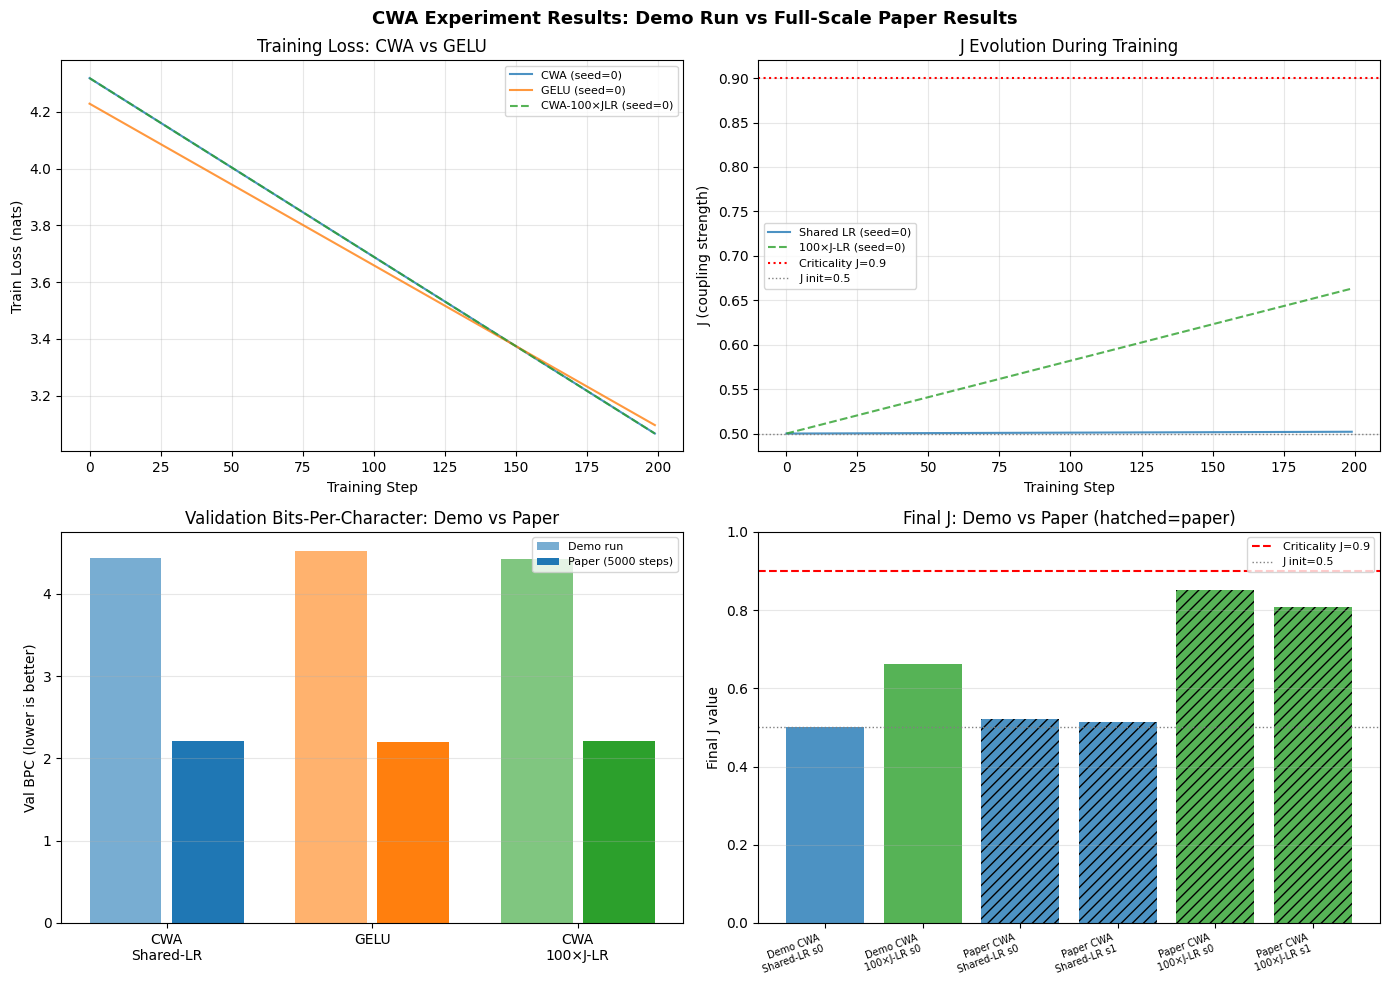


=== SUMMARY ===
Verdict: PARTIAL_CONFIRM
IFT confirmed: True
Paper CWA val BPC (5000 steps): 2.2104
Paper GELU val BPC (5000 steps): 2.1959
J moved with 100×LR (paper): True
Final J range (100×LR, paper): 0.807 - 0.851
Demo CWA val BPC (200 steps): 4.4279
Demo GELU val BPC (200 steps): 4.5243


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("CWA Experiment Results: Demo Run vs Full-Scale Paper Results", fontsize=13, fontweight='bold')

# --- Plot 1: Training loss curves ---
ax = axes[0, 0]
for r in results_b:
    steps = [t['step'] for t in r['trace']]
    losses = [t['train_loss'] for t in r['trace']]
    label = f"{r['model']} (seed={r['seed']})"
    color = 'tab:blue' if r['model'] == 'CWA' else 'tab:orange'
    ax.plot(steps, losses, color=color, alpha=0.8, label=label)
for r in results_c:
    steps = [t['step'] for t in r['trace']]
    losses = [t['train_loss'] for t in r['trace']]
    ax.plot(steps, losses, color='tab:green', alpha=0.8, linestyle='--', label=f"CWA-100×JLR (seed={r['seed']})")
ax.set_xlabel('Training Step')
ax.set_ylabel('Train Loss (nats)')
ax.set_title('Training Loss: CWA vs GELU')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Plot 2: J evolution ---
ax = axes[0, 1]
for r in results_b:
    if r['model'] == 'CWA':
        steps = [t['step'] for t in r['trace'] if t.get('J_mean') is not None]
        J_vals = [t['J_mean'] for t in r['trace'] if t.get('J_mean') is not None]
        ax.plot(steps, J_vals, color='tab:blue', alpha=0.8, label=f"Shared LR (seed={r['seed']})")
for r in results_c:
    steps = [t['step'] for t in r['trace'] if t.get('J_mean') is not None]
    J_vals = [t['J_mean'] for t in r['trace'] if t.get('J_mean') is not None]
    ax.plot(steps, J_vals, color='tab:green', linestyle='--', alpha=0.8, label=f"100×J-LR (seed={r['seed']})")
ax.axhline(y=0.9, color='red', linestyle=':', linewidth=1.5, label='Criticality J=0.9')
ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1, label='J init=0.5')
ax.set_xlabel('Training Step')
ax.set_ylabel('J (coupling strength)')
ax.set_title('J Evolution During Training')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Plot 3: Val BPC comparison ---
ax = axes[1, 0]
# Demo results
cwa_bpc_demo = [r['val_bpc'] for r in results_b if r['model'] == 'CWA']
gelu_bpc_demo = [r['val_bpc'] for r in results_b if r['model'] == 'GELU']
cwa100_bpc_demo = [r['val_bpc'] for r in results_c]

# Full-scale results from loaded data
meta = data['metadata']
cwa_bpc_paper = meta['sub_exp_b']['CWA_val_bpc_per_seed']
gelu_bpc_paper = meta['sub_exp_b']['GELU_val_bpc_per_seed']
cwa100_bpc_paper = meta['sub_exp_c']['high_lr_bpc_per_seed']

x_pos = [1, 2, 3]
demo_means = [
    sum(cwa_bpc_demo)/len(cwa_bpc_demo) if cwa_bpc_demo else 0,
    sum(gelu_bpc_demo)/len(gelu_bpc_demo) if gelu_bpc_demo else 0,
    sum(cwa100_bpc_demo)/len(cwa100_bpc_demo) if cwa100_bpc_demo else 0,
]
paper_means = [
    meta['sub_exp_b']['CWA_val_bpc_mean'],
    meta['sub_exp_b']['GELU_val_bpc_mean'],
    meta['sub_exp_c']['high_lr_bpc_mean'],
]
labels = ['CWA\nShared-LR', 'GELU', 'CWA\n100×J-LR']
colors = ['tab:blue', 'tab:orange', 'tab:green']

bars1 = ax.bar([x - 0.2 for x in x_pos], demo_means, 0.35, label='Demo run', color=colors, alpha=0.6)
bars2 = ax.bar([x + 0.2 for x in x_pos], paper_means, 0.35, label='Paper (5000 steps)', color=colors, alpha=1.0)
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_ylabel('Val BPC (lower is better)')
ax.set_title('Validation Bits-Per-Character: Demo vs Paper')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# --- Plot 4: J final values vs criticality ---
ax = axes[1, 1]
# Demo final J values
demo_J_shared = [r['final_J_mean'] for r in results_b if r['model'] == 'CWA' and r['final_J_mean'] is not None]
demo_J_100x = [r['final_J_mean'] for r in results_c if r['final_J_mean'] is not None]
# Paper final J values
paper_J_shared = meta['sub_exp_b']['CWA_final_J_mean']
paper_J_100x = meta['sub_exp_c']['final_J_mean_per_seed']

all_labels = []
all_vals = []
all_colors = []
all_hatch = []

for i, v in enumerate(demo_J_shared):
    all_labels.append(f'Demo CWA\nShared-LR s{i}')
    all_vals.append(v)
    all_colors.append('tab:blue')
    all_hatch.append('')
for i, v in enumerate(demo_J_100x):
    all_labels.append(f'Demo CWA\n100×J-LR s{i}')
    all_vals.append(v)
    all_colors.append('tab:green')
    all_hatch.append('')
for i, v in enumerate(paper_J_shared):
    all_labels.append(f'Paper CWA\nShared-LR s{i}')
    all_vals.append(v)
    all_colors.append('tab:blue')
    all_hatch.append('///')
for i, v in enumerate(paper_J_100x):
    all_labels.append(f'Paper CWA\n100×J-LR s{i}')
    all_vals.append(v)
    all_colors.append('tab:green')
    all_hatch.append('///')

bars = ax.bar(range(len(all_vals)), all_vals, color=all_colors, alpha=0.8)
for bar, hatch in zip(bars, all_hatch):
    bar.set_hatch(hatch)

ax.axhline(y=0.9, color='red', linestyle='--', linewidth=1.5, label='Criticality J=0.9')
ax.axhline(y=0.5, color='gray', linestyle=':', linewidth=1, label='J init=0.5')
ax.set_xticks(range(len(all_labels)))
ax.set_xticklabels(all_labels, fontsize=7, rotation=20, ha='right')
ax.set_ylabel('Final J value')
ax.set_title('Final J: Demo vs Paper (hatched=paper)')
ax.legend(fontsize=8)
ax.set_ylim(0, 1.0)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('cwa_results.png', dpi=100, bbox_inches='tight')
plt.show()
print("\n=== SUMMARY ===")
print(f"Verdict: {meta['verdict']}")
print(f"IFT confirmed: {meta['sub_exp_a']['ift_confirmed']}")
print(f"Paper CWA val BPC (5000 steps): {meta['sub_exp_b']['CWA_val_bpc_mean']:.4f}")
print(f"Paper GELU val BPC (5000 steps): {meta['sub_exp_b']['GELU_val_bpc_mean']:.4f}")
print(f"J moved with 100×LR (paper): {meta['sub_exp_c']['J_moved_detectably_any_seed']}")
print(f"Final J range (100×LR, paper): {min(meta['sub_exp_c']['final_J_mean_per_seed']):.3f} - {max(meta['sub_exp_c']['final_J_mean_per_seed']):.3f}")
print(f"Demo CWA val BPC ({N_STEPS} steps): {sum(r['val_bpc'] for r in results_b if r['model']=='CWA')/max(sum(1 for r in results_b if r['model']=='CWA'),1):.4f}")
print(f"Demo GELU val BPC ({N_STEPS} steps): {sum(r['val_bpc'] for r in results_b if r['model']=='GELU')/max(sum(1 for r in results_b if r['model']=='GELU'),1):.4f}")